(survival_recursive_preferences)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 递归偏好下的生存与长期动态

```{index} single: Survival; Recursive Preferences
```

```{contents} Contents
:depth: 2
```

## 概述

本讲座研究 {cite:t}`Borovicka2020` 中关于长期生存的理论。

经典的**市场选择假说**认为，信念较不准确的主体最终会被市场淘汰。

这一结果由 {cite:t}`Sandroni2000Markets` 和 {cite:t}`Blume_Easley2006` 针对具有可分 CRRA 偏好的经济体进行了严格证明。

Borovicka 表明，在 Epstein-Zin 递归偏好下，这一结论可能不成立。

在递归偏好下，具有扭曲信念的主体可以生存，甚至可以占据主导地位。

关键机制在于递归偏好将风险厌恶与跨期替代弹性(IES)分离开来。

这种分离产生了三个对生存至关重要的渠道：

1. *风险溢价渠道*奖励更乐观的主体持有更多的风险资产。
1. *投机波动率渠道*通过对数收益率波动率惩罚激进的头寸。
1. *储蓄渠道*在 IES 不等于 1 时改变消费和储蓄决策。

在可分偏好下，只有前两个渠道存在。

在递归偏好下，储蓄渠道可以推翻市场选择。

```{note}
本文建立在 {cite:t}`Duffie_Epstein1992a` 的连续时间递归效用表述之上，
并采用 {cite:t}`Dumas_Uppal_Wang2000` 的规划者问题方法。

市场选择假说的重要基础由
{cite:t}`DeLong_etal1991` 和 {cite:t}`Blume_Easley1992` 奠定。
```

我们从一些导入开始。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n

## 环境

该经济体包含两个无限期存活的主体，用 $n \in \{1, 2\}$ 索引。

这两个主体具有相同的递归偏好，但对总禀赋增长持有不同的信念。

我们将 Borovička 的信念扭曲 $u^n$ 记作 $\omega^n$。

### 总禀赋

在真实概率测度 $P$ 下，总禀赋满足

$$
d \log Y_t = \mu_Y dt + \sigma_Y dW_t, \quad Y_0 > 0
$$ (eq:srp_endowment)

其中 $W$ 是标准布朗运动，$\mu_Y$ 是漂移，$\sigma_Y > 0$ 是波动率。

### 异质信念

主体 $n$ 认为漂移是 $\mu_Y + \omega^n \sigma_Y$ 而非 $\mu_Y$。

参数 $\omega^n$ 在 $\omega^n > 0$ 时衡量乐观程度，在 $\omega^n < 0$ 时衡量悲观程度。

主体 $n$ 的主观概率测度 $Q^n$ 由 Radon–Nikodym 导数定义

$$
M_t^n = \frac{dQ^n}{dP}\bigg|_t = \exp\left(-\frac{1}{2} |\omega^n|^2 t + \omega^n W_t\right)
$$ (eq:radon_nikodym)

在 $Q^n$ 下，过程 $W_t^n = W_t - \omega^n t$ 是一个布朗运动，主体 $n$ 感知到

$$
d \log Y_t = (\mu_Y + \omega^n \sigma_Y) dt + \sigma_Y dW_t^n .
$$

$\omega^n > 0$ 的主体对禀赋增长持乐观态度，而 $\omega^n < 0$ 的主体则持悲观态度。

### 递归偏好

两个主体都具有 Epstein-Zin 递归偏好。

我们用 $\gamma > 0$ 表示相对风险厌恶，用 $\rho > 0$ 表示 IES 的倒数，用 $\beta > 0$ 表示时间偏好率。

Duffie-Epstein-Zin 幸福函数为

$$
F(C, \nu)
= \beta \frac{C^{1-\gamma}}{1-\gamma}
\cdot
\left(\frac{(1-\gamma) - (1-\rho)\nu / \beta}{\rho - \gamma}\right)^{(\gamma - \rho)/(1-\rho)}
$$ (eq:felicity)

其中 $\nu$ 是内生的贴现率。

```{note}
在离散时间中，Epstein-Zin 偏好通过 CES 聚合器将当前消费与未来效用的确定性等价物聚合在一起(参见 {doc}`advanced:doubts_or_variability`)。

在连续时间中不存在"下一期 $V_{t+1}$"，因此 {cite:t}`Duffie_Epstein1992a` 将该递归重新表述为一个依赖于主体自身延续值率 $\nu$ 的幸福函数 $F(C,\nu)$。

这两种表述编码了相同的风险厌恶 $\gamma$ 与 IES 倒数 $\rho$ 的分离。

当 $\gamma = \rho$ 时，偏好退化为标准的可分 CRRA 情形。
```

## 规划者问题

遵循 {cite:t}`Dumas_Uppal_Wang2000`，我们通过社会规划者问题来研究均衡配置。

规划者为两个主体选择消费份额 $z^1$ 和 $z^2 = 1 - z^1$ 以及贴现率过程 $\nu^n$。

### 修正贴现因子

将信念扭曲吸收进修正贴现因子 $\tilde{\lambda}^n = \lambda^n M^n$ 是很方便的，其中 $M^n$ 是 Radon-Nikodym 导数 {eq}`eq:radon_nikodym`。

这些过程满足

$$
d \log \tilde{\lambda}_t^n
= -\left(\nu_t^n + \frac{1}{2} (\omega^n)^2\right) dt + \omega^n dW_t .
$$ (eq:modified_discount)

```{exercise}
:label: ex_modified_discount

推导 {eq}`eq:modified_discount`。

*提示：* 使用 $\log \tilde{\lambda}^n = \log \lambda^n + \log M^n$。帕累托权重 $\lambda^n$ 按 $d\log \lambda_t^n = -\nu_t^n \, dt$ 演化，而 $\log M_t^n$ 由 {eq}`eq:radon_nikodym` 给出。
```

```{solution-start} ex_modified_discount
:class: dropdown
```

由定义 $\tilde{\lambda}^n = \lambda^n M^n$，我们有

$$
\log \tilde{\lambda}_t^n = \log \lambda_t^n + \log M_t^n.
$$

帕累托权重满足 $d\log \lambda_t^n = -\nu_t^n \, dt$。

由 {eq}`eq:radon_nikodym`，$\log M_t^n = -\frac{1}{2}|\omega^n|^2 t + \omega^n W_t$，因此

$$
d \log M_t^n = -\tfrac{1}{2}(\omega^n)^2 \, dt + \omega^n \, dW_t.
$$

将两者相加：

$$
d \log \tilde{\lambda}_t^n = -\nu_t^n \, dt - \tfrac{1}{2}(\omega^n)^2 \, dt + \omega^n \, dW_t = -\left(\nu_t^n + \tfrac{1}{2}(\omega^n)^2\right) dt + \omega^n \, dW_t.
$$

```{solution-end}
```

### 状态变量：帕累托份额

关键的状态变量是主体 1 的帕累托份额：

$$
\upsilon = \frac{\tilde{\lambda}^1}{\tilde{\lambda}^1 + \tilde{\lambda}^2} \in (0, 1)
$$ (eq:pareto_share)

它刻画了主体 1 在规划者配置中的相对权重。

定义对数几率比 $\vartheta = \log(\upsilon / (1 - \upsilon))$。

其动态为

$$
d\vartheta_t = \underbrace{\left[\nu_t^2 + \frac{1}{2}(\omega^2)^2 - \nu_t^1 - \frac{1}{2}(\omega^1)^2\right]}_{m_{\vartheta}(\upsilon_t)} dt + (\omega^1 - \omega^2) dW_t
$$ (eq:log_odds)

漂移 $m_\vartheta(\upsilon)$ 决定了帕累托份额的长期行为。

```{exercise}
:label: ex_log_odds

从 {eq}`eq:modified_discount` 和定义 $\vartheta = \log(\upsilon/(1-\upsilon))$ 推导 {eq}`eq:log_odds`。

*提示：* 首先证明 $\vartheta = \log \tilde{\lambda}^1 - \log \tilde{\lambda}^2$，然后将两个 SDE 相减。
```

```{solution-start} ex_log_odds
:class: dropdown
```

由于 $\upsilon = \tilde{\lambda}^1 / (\tilde{\lambda}^1 + \tilde{\lambda}^2)$，我们有 $1 - \upsilon = \tilde{\lambda}^2 / (\tilde{\lambda}^1 + \tilde{\lambda}^2)$，因此

$$
\vartheta = \log\frac{\upsilon}{1-\upsilon} = \log \tilde{\lambda}^1 - \log \tilde{\lambda}^2.
$$

由 {eq}`eq:modified_discount`，两个对数贴现因子的 SDE 为

$$
d\log \tilde{\lambda}^1_t = -\left(\nu_t^1 + \tfrac{1}{2}(\omega^1)^2\right)dt + \omega^1 dW_t,
$$

$$
d\log \tilde{\lambda}^2_t = -\left(\nu_t^2 + \tfrac{1}{2}(\omega^2)^2\right)dt + \omega^2 dW_t.
$$

用第一个减去第二个：

$$
d\vartheta_t = \left[\nu_t^2 + \tfrac{1}{2}(\omega^2)^2 - \nu_t^1 - \tfrac{1}{2}(\omega^1)^2\right]dt + (\omega^1 - \omega^2)dW_t.
$$

```{solution-end}
```

### HJB 方程

齐次性将规划者问题简化为关于单一状态变量 $\upsilon$ 的非线性 ODE。

因为每个主体的效用关于消费是 $1-\gamma$ 次齐次的，规划者的值函数可以分解为 $J(\upsilon, Y) = \tilde{J}(\upsilon) \cdot Y^{1-\gamma}/(1-\gamma)$，从而消除了 $Y$ 作为状态变量。

#### 从离散时间到连续时间

在离散时间中，规划者通过在每个日期选择配置来最大化主体效用的加权和。

贝尔曼方程为

$$
\tilde{J}(\upsilon) = \max_{z^1, z^2} \left\{ \upsilon \, u(z^1) + (1-\upsilon) \, u(z^2) + \beta \, \mathbb{E}\left[\tilde{J}(\upsilon')\right] \right\}.
$$

在连续时间中，时期长度缩小为 $dt$。

$[t, t+dt)$ 上的"流量收益"变为 $\left[\upsilon F(z^1, \nu^1) + (1-\upsilon)F(z^2, \nu^2)\right] dt$，其中 $F$ 是 Duffie-Epstein-Zin 幸福函数 {eq}`eq:felicity`。

值函数在 $dt$ 上的期望变化由**无穷小生成元** $\mathcal{L}$ 捕获。

对于扩散过程 $d\upsilon = m \, dt + s \, dW$，伊藤引理给出

$$
\mathcal{L}\tilde{J}(\upsilon) = m(\upsilon)\,\tilde{J}'(\upsilon) + \tfrac{1}{2} s(\upsilon)^2 \, \tilde{J}''(\upsilon),
$$

其中 $m$ 和 $s$ 是帕累托份额的漂移和扩散。

这是 $\beta \, \mathbb{E}[\tilde{J}(\upsilon')] - \tilde{J}(\upsilon)$ 的连续时间类比：它衡量随着 $\upsilon$ 演化，值函数如何漂移和波动。

令流量收益加上期望资本收益等于零，得到示意性的 HJB 方程：

$$
0 = \sup_{(z^1,z^2,\nu^1,\nu^2)} \left\{ \upsilon F(z^1, \nu^1) + (1-\upsilon) F(z^2, \nu^2) + \mathcal{L} \tilde{J}(\upsilon) \right\}
$$ (eq:hjb_sketch)

满足约束 $z^1 + z^2 \leq 1$。

#### 精确的约化 ODE

{cite:t}`Borovicka2020` 的命题 2.3 在代入齐次性约化 $J(\tilde{\lambda}, Y) = (\tilde{\lambda}^1 + \tilde{\lambda}^2) Y^{1-\gamma} \tilde{J}(\upsilon)$ 以及 $\upsilon$ 和 $Y$ 的动态后，给出了精确的 HJB 方程：

$$
0 = \sup_{(z^1, z^2, \nu^1, \nu^2)} \;
\upsilon \, F(z^1, \nu^1) + (1 - \upsilon) \, F(z^2, \nu^2)
$$ (eq:hjb)

$$
+ \left[
-\upsilon \nu^1 - (1-\upsilon)\nu^2
+ \bigl(\upsilon \omega^1 + (1-\upsilon)\omega^2\bigr)(1-\gamma)\sigma_Y
+ (1-\gamma)\mu_Y
+ \tfrac{1}{2}(1-\gamma)^2 \sigma_Y^2
\right] \tilde{J}(\upsilon)
$$

$$
+ \upsilon(1-\upsilon)
\left[\nu^2 - \nu^1 + (\omega^1 - \omega^2)(1-\gamma)\sigma_Y\right]
\tilde{J}'(\upsilon)
$$

$$
+ \tfrac{1}{2}\upsilon^2(1-\upsilon)^2 (\omega^1 - \omega^2)^2 \,
\tilde{J}''(\upsilon)
$$

满足约束 $z^1 + z^2 \leq 1$。

第一行是来自两个主体幸福函数的流量收益。

第二行将 $\tilde{J}(\upsilon)$ 乘以一个结合了主体贴现率、信念加权的禀赋漂移以及方差修正的项——这些来自于通过伊藤引理吸收 $Y^{1-\gamma}$ 因子。

第三行将 $\tilde{J}'(\upsilon)$ 乘以帕累托份额的漂移，它取决于贴现率的差异以及对禀赋风险的信念加权响应。

第四行将 $\tilde{J}''(\upsilon)$ 乘以帕累托份额扩散的平方。

边界条件为 $\tilde{J}(0) = \tilde{V}^2$ 和 $\tilde{J}(1) = \tilde{V}^1$，其中 $\tilde{V}^n$ 是仅由主体 $n$ 单独构成的齐次经济体中的延续值。

这是 {cite:t}`Blume_Easley2006` 中离散时间规划者问题的连续时间对应(另见 {doc}`likelihood_ratio_process_2`)。


## 生存条件

核心结果通过 $m_\vartheta(\upsilon)$ 的边界行为来刻画生存。

```{prf:proposition}
:label: survival_conditions

定义以下排斥条件 (i) 和 (ii) 及其吸引对应条件 (i') 和 (ii')：

$$
\text{(i)} \lim_{\upsilon \searrow 0} m_\vartheta(\upsilon) > 0, \qquad
\text{(i')} \lim_{\upsilon \searrow 0} m_\vartheta(\upsilon) < 0
$$

$$
\text{(ii)} \lim_{\upsilon \nearrow 1} m_\vartheta(\upsilon) < 0, \qquad
\text{(ii')} \lim_{\upsilon \nearrow 1} m_\vartheta(\upsilon) > 0
$$

那么：

*(a)* 若 (i) 和 (ii) 成立，则两个主体在 $P$ 下都生存。

*(b)* 若 (i) 和 (ii') 成立，则主体 1 在 $P$ 下长期占据主导地位。

*(c)* 若 (i') 和 (ii) 成立，则主体 2 在 $P$ 下长期占据主导地位。

*(d)* 若 (i') 和 (ii') 成立，则每个主体都以严格正概率占据主导地位。
```

该证明使用了扩散过程边界行为的 Feller 分类，如 {cite:t}`Karlin_Taylor1981` 所述。

条件 (i) 表明，当主体 1 接近消亡时，存在一种将其份额推回上升的力量。

条件 (ii) 表明，当主体 1 接近吸收整个经济体时，存在一种将其份额推回下降的力量。

当两种力量都存在时，帕累托份额是常返的，两个主体都生存。

## 财富动态分解

我们现在用均衡财富动态重写 {prf:ref}`survival_conditions` 中的生存条件。

当且仅当主体 1 在其规模微不足道时财富增长快于主体 2，主体 1 才能在接近消亡时生存下来。

当 $\upsilon \searrow 0$ 时，价格完全由主体 2 决定，仿佛经济体是齐次的。

主体 1 是主体 2 经济体中的价格接受者。

令 $m_A^n(\upsilon)$ 表示主体 $n$ 财富的期望对数增长率。

其差异分解为两个渠道：

$$
\lim_{\upsilon \searrow 0} [m_A^1(\upsilon) - m_A^2(\upsilon)]
= \underbrace{\lim_{\upsilon \searrow 0} [m_R^1(\upsilon) - m_R^2(\upsilon)]}_{\text{组合收益}}
+ \underbrace{\lim_{\upsilon \searrow 0} [(y^2(\upsilon))^{-1} - (y^1(\upsilon))^{-1}]}_{\text{消费-财富比}}
$$ (eq:wealth_decomp)

第一项衡量主体 1 的投资组合增长快多少。

第二项衡量主体 1 从财富中消费少多少——较低的消费-财富比意味着更多的储蓄和更快的财富积累。

当此总差异为正时，主体 1 生存；当为负时，她朝着消亡收缩。

```{exercise}
:label: ex_wealth_decomp

推导 {eq}`eq:wealth_decomp`。

令 $A^n$ 表示主体 $n$ 的财富，$C^n$ 表示她的消费。

预算约束为 $dA^n = A^n dR^n - C^n dt$，其中 $dR^n$ 是主体 $n$ 投资组合的收益。

定义消费-财富比 $c^n = C^n / A^n = (y^n)^{-1}$。

证明 $d\log A^n = m_R^n \, dt - (y^n)^{-1} dt + \ldots$，因此期望对数财富增长之差为 $m_A^1 - m_A^2 = (m_R^1 - m_R^2) + [(y^2)^{-1} - (y^1)^{-1}]$。
```

```{solution-start} ex_wealth_decomp
:class: dropdown
```

将预算约束除以 $A^n$：

$$
\frac{dA^n}{A^n} = dR^n - (y^n)^{-1} dt.
$$

由伊藤引理，$d\log A^n = \frac{dA^n}{A^n} - \frac{1}{2}\left(\frac{dA^n}{A^n}\right)^2$。

将 $dR^n = m_R^n \, dt + \sigma_R^n \, dW$ 写出($P$ 下的投资组合收益)。

那么

$$
d\log A^n = \left(m_R^n - (y^n)^{-1} - \tfrac{1}{2}(\sigma_R^n)^2\right) dt + \sigma_R^n \, dW.
$$

对主体 1 和 2 取差：

$$
m_A^1 - m_A^2 = (m_R^1 - m_R^2) + \left[(y^2)^{-1} - (y^1)^{-1}\right] - \tfrac{1}{2}\left[(\sigma_R^1)^2 - (\sigma_R^2)^2\right].
$$

当我们将 $m_R^n$ 定义为期望对数投资组合收益(即 $\log R^n$ 的漂移而非算术收益)时，波动率项 $\tfrac{1}{2}[(\sigma_R^1)^2 - (\sigma_R^2)^2]$ 被吸收进 $m_R^1 - m_R^2$，从而得到 {eq}`eq:wealth_decomp`。

```{solution-end}
```

### 组合收益

在边界 $\upsilon \searrow 0$ 处，期望对数投资组合收益之差为

$$
\lim_{\upsilon \searrow 0} [m_R^1 - m_R^2]
= \underbrace{\frac{\omega^1 - \omega^2}{\gamma \sigma_Y}}_{\text{风险份额之差}}
\cdot \underbrace{(\gamma \sigma_Y^2 - \omega^2 \sigma_Y)}_{\text{风险溢价}}
- \underbrace{\frac{\omega^1 - \omega^2}{\gamma}
\left(\sigma_Y + \frac{\omega^1 - \omega^2}{2\gamma}\right)}_{\text{波动率项}}
$$ (eq:portfolio_returns)

乐观的主体($\omega^1 > \omega^2$)相对于主体 2 将风险资产超配 $(\omega^1 - \omega^2)/(\gamma \sigma_Y)$，并从这一额外敞口中赚取股权风险溢价。

被减去的*波动率惩罚*反映了持有更极端投资组合的成本：对数收益率的较高方差拖累了期望对数财富增长。

此项依赖于风险厌恶 $\gamma$，但不依赖于 IES，因为投资组合选择仅由风险厌恶决定。

```{exercise}
:label: ex_portfolio_returns

推导 {eq}`eq:portfolio_returns`。

在边界 $\upsilon \searrow 0$ 处，主体 $n$ 的最优风险资产份额为 $\pi^n = 1 + (\omega^n - \omega^2)/(\gamma \sigma_Y)$(参见 {eq}`eq:portfolio`)。

令 $\bar{\mu}_R = \mu_Y + \gamma \sigma_Y^2 - \omega^2 \sigma_Y$ 表示 $P$ 下风险资产的期望收益，$r$ 表示无风险利率。

连续再平衡的投资组合具有期望对数收益 $m_R^n = r + \pi^n(\bar{\mu}_R - r) - \frac{1}{2}(\pi^n)^2 \sigma_Y^2$。

计算 $m_R^1 - m_R^2$ 并化简。
```

```{solution-start} ex_portfolio_returns
:class: dropdown
```

使用 $m_R^n = r + \pi^n(\bar{\mu}_R - r) - \frac{1}{2}(\pi^n)^2 \sigma_Y^2$，差异为

$$
m_R^1 - m_R^2 = (\pi^1 - \pi^2)(\bar{\mu}_R - r) - \tfrac{1}{2}[(\pi^1)^2 - (\pi^2)^2]\sigma_Y^2.
$$

风险份额之差为 $\pi^1 - \pi^2 = (\omega^1 - \omega^2)/(\gamma \sigma_Y)$。

算术股权溢价为 $\bar{\mu}_R - r = \gamma \sigma_Y^2 - \omega^2 \sigma_Y$，因此：

$$
(\pi^1 - \pi^2)(\bar{\mu}_R - r) = \frac{\omega^1 - \omega^2}{\gamma \sigma_Y} \cdot (\gamma \sigma_Y^2 - \omega^2 \sigma_Y).
$$

对于波动率项，写出 $(\pi^1)^2 - (\pi^2)^2 = (\pi^1 - \pi^2)(\pi^1 + \pi^2)$ 并注意 $\pi^1 + \pi^2 = 2 + (\omega^1 + \omega^2 - 2\omega^2)/(\gamma \sigma_Y)$。

化简后：

$$
\tfrac{1}{2}[(\pi^1)^2 - (\pi^2)^2]\sigma_Y^2 = \frac{\omega^1 - \omega^2}{\gamma}\left(\sigma_Y + \frac{\omega^1 - \omega^2}{2\gamma}\right).
$$

将两部分合并即得 {eq}`eq:portfolio_returns`。

```{solution-end}
```

### 消费-财富比

在边界处消费-财富比之差为

$$
\lim_{\upsilon \searrow 0} [(y^2)^{-1} - (y^1)^{-1}]
= \frac{1-\rho}{\rho} \left[(\omega^1 - \omega^2)\sigma_Y + \frac{(\omega^1 - \omega^2)^2}{2\gamma}\right]
$$ (eq:consumption_rates)

括号中的项是*主观*期望投资组合收益之差——即主体 1 相对于主体 2 认为她所赚取的收益。

因子 $(1-\rho)/\rho$ 将这种感知到的收益优势转化为储蓄响应。

- 当 IES $> 1$($\rho < 1$)时，因子为正：更高的感知收益使主体储蓄更多，因为替代效应主导了收入效应。
- 当 IES $< 1$($\rho > 1$)时，因子为负：收入效应占主导，主体储蓄更少，不利于生存。
- 当 IES $= 1$($\rho = 1$)时，两种效应相互抵消，储蓄渠道完全消失。

这就是递归偏好通过将 $\gamma$ 与 $\rho$ 分离来改变生存结果的渠道。

```{exercise}
:label: ex_consumption_wealth

推导 {eq}`eq:consumption_rates`。

在由主体 2 构成的齐次经济体中，消费-财富比为 $(y(0))^{-1} = \beta - (1-\rho)\mu_V^2$，其中 $\mu_V^2$ 是主体 2 财富的期望对数收益。

作为微不足道的价格接受者，主体 1 的消费-财富比为 $(y^1)^{-1} = \beta - (1-\rho)\mu_V^1$，其中 $\mu_V^1$ 是她自己的期望对数收益。

使用 $(y^2)^{-1} - (y^1)^{-1} = (1-\rho)(\mu_V^1 - \mu_V^2)$，并用主体 1 的*主观*期望超额收益表示 $\mu_V^1 - \mu_V^2$。

*提示：* 在主体 1 的信念下，她的投资组合在期望对数收益方面相对于主体 2 的投资组合多赚 $(\omega^1 - \omega^2)\sigma_Y + (\omega^1 - \omega^2)^2/(2\gamma)$。
```

```{solution-start} ex_consumption_wealth
:class: dropdown
```

主体 $n$ 的消费-财富比满足 $(y^n)^{-1} = \beta - (1-\rho)\mu_V^n$，其中 $\mu_V^n$ 是主体 $n$ 在其自身主观测度下财富的期望对数收益。

取差：

$$
(y^2)^{-1} - (y^1)^{-1} = (1-\rho)(\mu_V^1 - \mu_V^2).
$$

主体 1 的主观期望对数投资组合收益超过主体 2 的部分，等于她认为通过向风险资产倾斜所获得的收益。

她额外的风险份额为 $\pi^1 - 1 = (\omega^1 - \omega^2)/(\gamma\sigma_Y)$，而在她的主观测度 $Q^1$ 下风险资产的期望超额对数收益为 $(\gamma\sigma_Y^2 + (\omega^1 - \omega^2)\sigma_Y - \omega^2\sigma_Y) - r - \frac{1}{2}\sigma_Y^2$。

化简后，主观期望对数收益之差为

$$
\mu_V^1 - \mu_V^2 = (\omega^1 - \omega^2)\sigma_Y + \frac{(\omega^1 - \omega^2)^2}{2\gamma}.
$$

代入并整体除以 $\rho$(由 $(y^n)^{-1}$ 与 $\beta$ 之间的关系)：

$$
(y^2)^{-1} - (y^1)^{-1} = \frac{1-\rho}{\rho}\left[(\omega^1 - \omega^2)\sigma_Y + \frac{(\omega^1 - \omega^2)^2}{2\gamma}\right].
$$

```{solution-end}
```

### 两个比较静态分析

生存取决于 $\gamma$、$\rho$ 以及信噪比 $\omega^1 / \sigma_Y$ 和 $\omega^2 / \sigma_Y$，而非分别取决于 $\omega^1$、$\omega^2$ 和 $\sigma_Y$。

生存条件不依赖于 $\beta$ 或 $\mu_Y$，它们影响消费和价格的水平，但不影响边界处的相对财富动态。

In [2]:
def portfolio_return_diff(ω_1, ω_2, γ, σ_y):
    """
    边界处期望对数投资组合收益之差。
    """
    Δω = ω_1 - ω_2
    risky_share_diff = Δω / (γ * σ_y)
    risk_premium = γ * σ_y**2 - ω_2 * σ_y
    volatility_term = (Δω / γ) * (σ_y + 0.5 * Δω / γ)
    return risky_share_diff * risk_premium - volatility_term


def saving_channel(ω_1, ω_2, γ, ρ, σ_y):
    """
    边界处消费-财富比之差。
    """
    Δω = ω_1 - ω_2
    subjective_return_diff = Δω * σ_y + Δω**2 / (2 * γ)
    return (1 - ρ) / ρ * subjective_return_diff


def boundary_drift(ω_1, ω_2, γ, ρ, σ_y):
    """
    当主体 1 变得微不足道时的边界漂移 m_ϑ。

    正漂移意味着主体 1 生存(排斥边界)。
    """
    return γ * (
        portfolio_return_diff(ω_1, ω_2, γ, σ_y)
        + saving_channel(ω_1, ω_2, γ, ρ, σ_y)
    )

## 生存区域

{cite:t}`Borovicka2020` 的一个核心贡献是刻画了 $(\gamma, \rho)$ 平面中的生存区域。

在可分偏好下，$\gamma = \rho$，信念更准确的主体总是占据主导地位。

在递归偏好下，{prf:ref}`survival_conditions` 中的所有四种结果都可能出现。

文中的图 2 研究了主体 2 具有正确信念的情形，即 $\omega^2 = 0$。

下一个单元遵循该图。

In [3]:
def compute_survival_boundary(ω_1, ω_2, σ_y, γ_grid, boundary="lower"):
    """
    计算 (γ, ρ) 空间中边界漂移为零的曲线。

    对于 boundary='lower'，主体 1 是小主体。
    对于 boundary='upper'，主体 2 是小主体。
    """
    ρ_boundary = []

    if boundary == "lower":
        small_agent = (ω_1, ω_2)
    else:
        small_agent = (ω_2, ω_1)

    ω_small, ω_large = small_agent

    for γ in γ_grid:
        pr = portfolio_return_diff(ω_small, ω_large, γ, σ_y)
        Δω = ω_small - ω_large
        subj_ret = Δω * σ_y + Δω**2 / (2 * γ)

        if abs(subj_ret) < 1e-14:
            ρ_boundary.append(np.nan)
            continue

        denom = subj_ret - pr
        if abs(denom) < 1e-14:
            ρ_boundary.append(np.nan)
        else:
            ρ_boundary.append(subj_ret / denom)

    return np.asarray(ρ_boundary)


def compute_limit_boundary(γ_grid, boundary="lower"):
    """
    极限 |ω_1| / σ_y -> ∞ 的边界曲线。

    这等价于文中讨论的常数禀赋情形。
    """
    if boundary == "lower":
        return γ_grid / (1 + γ_grid)

    ρ = np.full_like(γ_grid, np.nan, dtype=float)
    mask = γ_grid < 1
    ρ[mask] = γ_grid[mask] / (1 - γ_grid[mask])
    return ρ

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


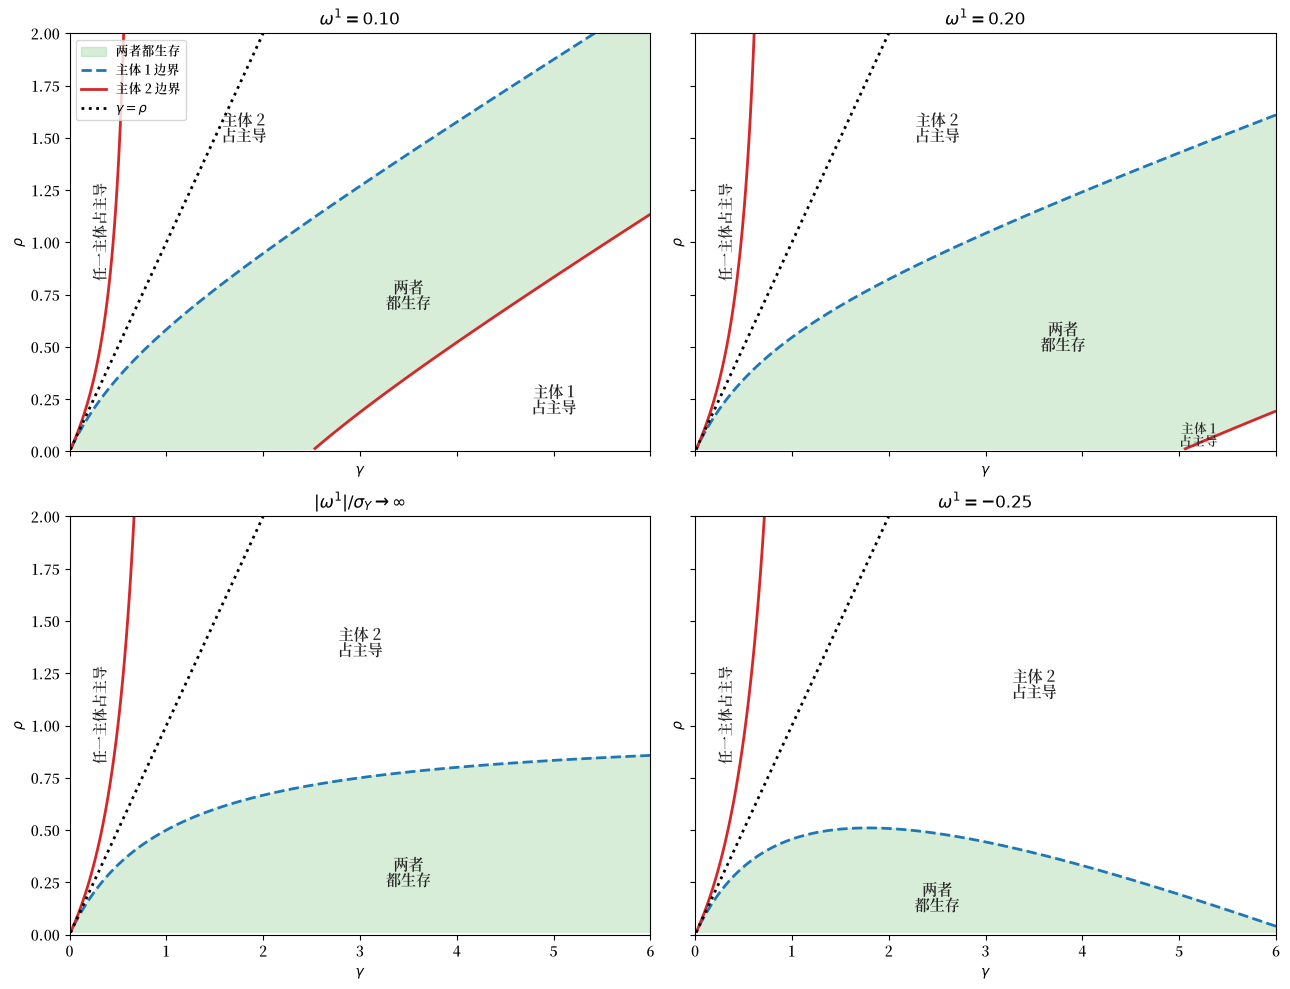

In [4]:
σ_y = 0.02
γ_vals = np.linspace(0.01, 6.0, 500)
ρ_vals = np.linspace(0.01, 2.0, 400)
G, R = np.meshgrid(γ_vals, ρ_vals)

panel_specs = [
    ("finite", 0.10, r"$\omega^1 = 0.10$"),
    ("finite", 0.20, r"$\omega^1 = 0.20$"),
    ("limit", None, r"$|\omega^1| / \sigma_Y \to \infty$"),
    ("finite", -0.25, r"$\omega^1 = -0.25$"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True)

for idx, (case, value, label) in enumerate(panel_specs):
    ax = axes.flat[idx]

    if case == "limit":
        ρ_1 = compute_limit_boundary(γ_vals, boundary="lower")
        ρ_2 = compute_limit_boundary(γ_vals, boundary="upper")
        # 极限边界漂移：使用闭式表达式
        # 当 ρ < γ/(1+γ) 时 m0 > 0(主体 1 生存)
        m0 = G - (1 + G) * R
        # 当 γ<1 时 ρ < γ/(1-γ) 时 m1 < 0(主体 2 生存)，γ>=1 时总成立
        m1 = (1 - G) * R - G
    else:
        ρ_1 = compute_survival_boundary(value, 0.0, σ_y, γ_vals,
                                        boundary="lower")
        ρ_2 = compute_survival_boundary(value, 0.0, σ_y, γ_vals,
                                        boundary="upper")
        # 在网格上评估边界漂移
        m0 = boundary_drift(value, 0.0, G, R, σ_y)
        m1 = -boundary_drift(0.0, value, G, R, σ_y)

    # 对所有四个区域进行分类
    both = (m0 > 0) & (m1 < 0)
    ag1_dom = (m0 > 0) & (m1 > 0)
    ag2_dom = (m0 < 0) & (m1 < 0)
    either = (m0 < 0) & (m1 > 0)

    # 对共存区域着色
    ax.contourf(G, R, both.astype(float), levels=[0.5, 1.5],
                colors=["C2"], alpha=0.18)
    if idx == 0:
        ax.fill_between([], [], color="C2", alpha=0.18,
                        label="两者都生存")

    # 绘制边界曲线
    ax.contour(G, R, m0, levels=[0], colors=["C0"],
               linestyles="--", linewidths=2)
    ax.contour(G, R, m1, levels=[0], colors=["C3"],
               linestyles="-", linewidths=2)
    if idx == 0:
        ax.plot([], [], "--", color="C0", lw=2, label="主体 1 边界")
        ax.plot([], [], "-", color="C3", lw=2, label="主体 2 边界")

    ax.plot(
        γ_vals, γ_vals, ":", color="black", lw=2,
        label=r"$\gamma = \rho$" if idx == 0 else None
    )

    tkw = dict(ha="center", va="center", style="italic", color="0.15")
    if case == "finite" and value == 0.10:
        ax.text(0.31, 1.05, "任一主体占主导", rotation=90,
                fontsize=10, **tkw)
        ax.text(1.8, 1.55, "主体 2\n占主导", fontsize=11, **tkw)
        ax.text(3.5, 0.75, "两者\n都生存", fontsize=11, **tkw)
        if ag1_dom.any():
            ax.text(5.0, 0.25, "主体 1\n占主导", fontsize=11, **tkw)
    elif case == "finite" and value == 0.20:
        ax.text(0.31, 1.05, "任一主体占主导", rotation=90,
                fontsize=10, **tkw)
        ax.text(2.5, 1.55, "主体 2\n占主导", fontsize=11, **tkw)
        ax.text(3.8, 0.55, "两者\n都生存", fontsize=11, **tkw)
        if ag1_dom.any():
            ax.text(5.2, 0.08, "主体 1\n占主导", fontsize=9, **tkw)
    elif case == "limit":
        ax.text(0.31, 1.05, "任一主体占主导", rotation=90,
                fontsize=10, **tkw)
        ax.text(3.0, 1.40, "主体 2\n占主导", fontsize=11, **tkw)
        ax.text(3.5, 0.30, "两者\n都生存", fontsize=11, **tkw)
    elif case == "finite" and value == -0.25:
        ax.text(0.31, 1.05, "任一主体占主导", rotation=90,
                fontsize=10, **tkw)
        ax.text(3.5, 1.20, "主体 2\n占主导", fontsize=11, **tkw)
        ax.text(2.5, 0.18, "两者\n都生存", fontsize=11, **tkw)

    ax.set_title(label, fontsize=12)
    ax.set_xlim(0, 6)
    ax.set_ylim(0, 2)
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel(r"$\rho$")

axes[0, 0].legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

每个面板针对主体 1 的信念扭曲 $\omega^1$ 的不同取值(主体 2 具有正确信念，$\omega^2 = 0$)绘制 $(\gamma, \rho)$ 平面中的两条曲线。

- 虚线(蓝色)是 $\upsilon = 0$ 处边界漂移等于零的地方——{prf:ref}`survival_conditions` 中的条件 (i)。
- 实线(红色)是 $\upsilon = 1$ 处边界漂移等于零的地方——条件 (ii)。
- 两条曲线之间的阴影区域是两个主体都生存的地方。
- 虚线对角线 $\gamma = \rho$ 是可分 CRRA 情形，沿此线信念更准确的主体总是占据主导地位。

适度乐观($\omega^1 = 0.10$)产生了一个宽阔的共存区域，横跨大部分 $\gamma$ 范围。

较强的乐观($\omega^1 = 0.20$)缩小了该区域：主体 2 边界对于中等和较大的 $\gamma$ 移出了绘图范围，缩小了两个主体共存的 $(\gamma, \rho)$ 对的集合。

在极限 $|\omega^1|/\sigma_Y \to \infty$(左下)中，边界简化为闭式表达式。

共存区域变窄，但在主体 2 边界曲线下方延伸到较大的 $\gamma$ 值。

悲观的扭曲($\omega^1 = -0.25$，右下)也可以生存，但仅在参数空间中窄得多的部分。

## 三个生存渠道

上述分解可以直接可视化。

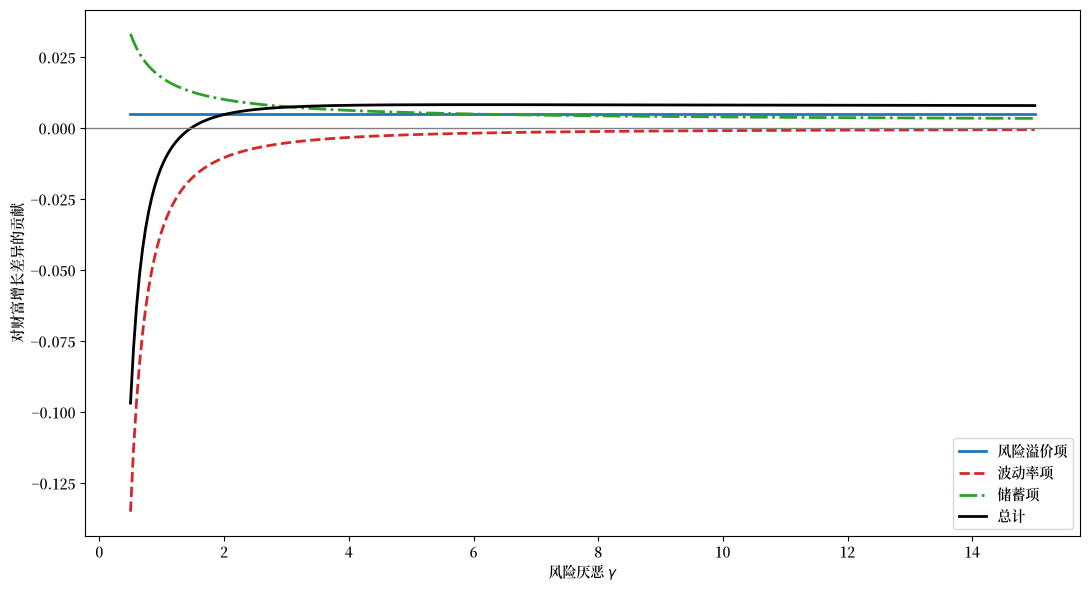

In [5]:
def decompose_survival(ω_1, ω_2, γ_grid, ρ, σ_y):
    """
    分解命题 3.4 中的财富增长差异。
    """
    Δω = ω_1 - ω_2
    risk_premium_term = Δω * (γ_grid * σ_y - ω_2) / γ_grid
    volatility_term = -(Δω / γ_grid) * (σ_y + 0.5 * Δω / γ_grid)
    saving_term = (1 - ρ) / ρ * (Δω * σ_y + Δω**2 / (2 * γ_grid))
    total = risk_premium_term + volatility_term + saving_term
    return risk_premium_term, volatility_term, saving_term, total


ω_1 = 0.25
ω_2 = 0.0
ρ = 0.67
σ_y = 0.02
γ_grid = np.linspace(0.5, 15.0, 300)

risk_term, vol_term, save_term, total = decompose_survival(
    ω_1, ω_2, γ_grid, ρ, σ_y
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(γ_grid, risk_term, color="C0", lw=2, label="风险溢价项")
ax.plot(γ_grid, vol_term, "--", color="C3", lw=2, label="波动率项")
ax.plot(γ_grid, save_term, "-.", color="C2", lw=2, label="储蓄项")
ax.plot(γ_grid, total, color="black", lw=2, label="总计")
ax.axhline(0, color="gray", lw=1)
ax.set_xlabel(r"风险厌恶 $\gamma$")
ax.set_ylabel("对财富增长差异的贡献")
ax.legend()
plt.tight_layout()
plt.show()

此图将 $\upsilon = 0$ 处的边界漂移分解为三项，针对一个乐观主体($\omega^1 = {0.25}$，$\omega^2 = 0$)，其 IES $= 1/\rho \approx 1.49$，$\sigma_Y = 0.02$。

- 风险溢价项(蓝色)始终为正，因为乐观主体超配了风险资产并赚取了股权溢价。
- 波动率项(红色虚线)为负且在低 $\gamma$ 时较大，反映了持有波动投资组合的成本。
- 储蓄项(绿色点划线)在 IES $> 1$ 时为正，因为乐观主体感知到财富的高收益并更激进地储蓄。
- 总计(黑色)在临界 $\gamma$ 处穿过零点，低于此值波动率惩罚占主导，主体无法生存。

## 改变 IES

储蓄项的符号由 IES 确定。

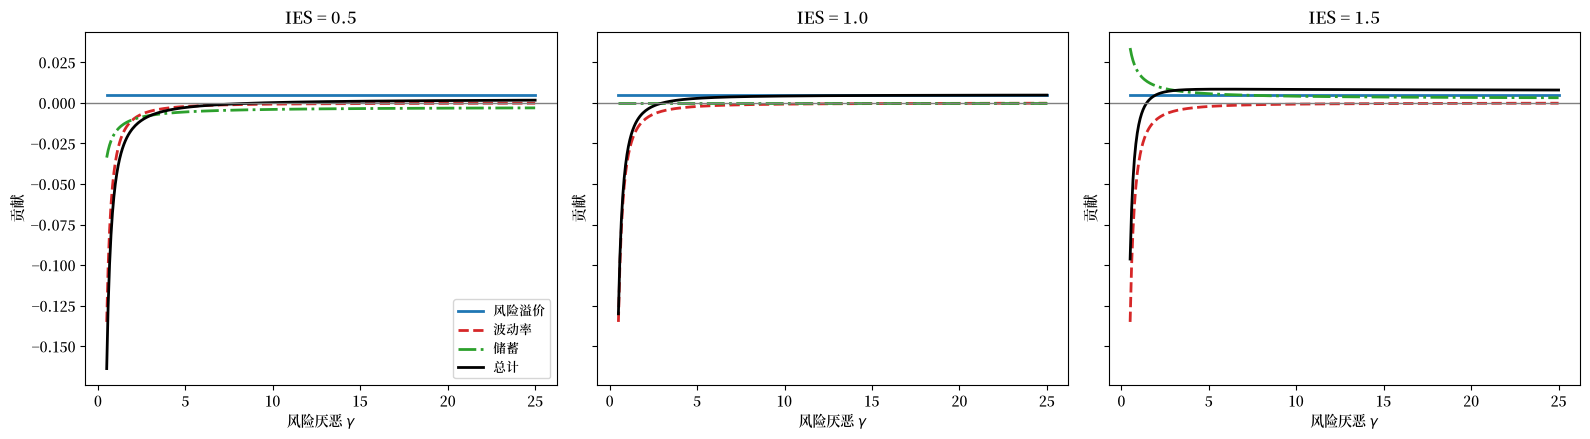

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

ω_1 = 0.25
ω_2 = 0.0
σ_y = 0.02
γ_grid = np.linspace(0.5, 25.0, 300)

ies_values = [0.5, 1.0, 1.5]

for idx, ies in enumerate(ies_values):
    ρ = 1.0 / ies
    risk_term, vol_term, save_term, total = decompose_survival(
        ω_1, ω_2, γ_grid, ρ, σ_y
    )

    ax = axes[idx]
    ax.plot(γ_grid, risk_term, color="C0", lw=2, label="风险溢价")
    ax.plot(γ_grid, vol_term, "--", color="C3", lw=2, label="波动率")
    ax.plot(γ_grid, save_term, "-.", color="C2", lw=2, label="储蓄")
    ax.plot(γ_grid, total, color="black", lw=2, label="总计")
    ax.axhline(0, color="gray", lw=1)
    ax.set_title(f"IES = {ies:.1f}", fontsize=12)
    ax.set_xlabel(r"风险厌恶 $\gamma$")
    ax.set_ylabel("贡献")

axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()

每个面板显示与前一图相同的三项分解，但现在针对三种不同的 IES 值($\omega^1 = 0.25$，$\omega^2 = 0$，$\sigma_Y = 0.02$)。

- 左面板(IES $= 0.5$)：储蓄项为负，因此乐观主体实际上储蓄更少，不利于生存。
- 中面板(IES $= 1.0$)：储蓄项完全消失，因此只剩下投资组合收益和波动率渠道。

    - 这消除了储蓄渠道，但本身并不能重现完整的可分 CRRA 基准，后者要求 $\gamma = \rho$(即 IES $= 1/\gamma$)，而不仅仅是 $\rho = 1$。
- 右面板(IES $= 1.5$)：储蓄项为正并将总漂移向上移动，扩大了乐观主体生存的 $\gamma$ 值范围。

## 渐近结果

Borovicka 推导了几个有用的渐近结果。

1. 当 $\gamma \searrow 0$ 时，每个主体都以严格正概率占据主导地位。
1. 当 $\gamma \nearrow \infty$ 时，相对更乐观的主体占据主导地位。
1. 当 $\rho \searrow 0$ 时，相对更乐观的主体总是生存。
   - 当风险厌恶足够低时，相对更悲观的主体也可以生存。
1. 当 $\rho \nearrow \infty$ 时，非退化的长期均衡不可能存在。

下一个图通过绘制 $\gamma$ 变小时的两个边界漂移来说明第一个结果。

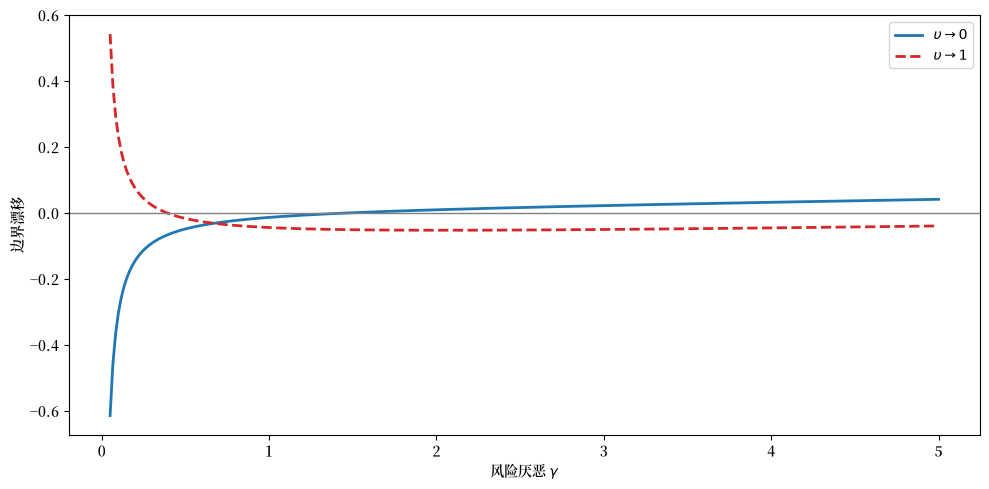

In [7]:
ω_1 = 0.25
ω_2 = 0.0
ρ = 0.67
σ_y = 0.02
γ_grid = np.linspace(0.05, 5.0, 300)

drift_at_0 = np.array([boundary_drift(ω_1, ω_2, γ, ρ, σ_y) for γ in γ_grid])
drift_at_1 = np.array([-boundary_drift(ω_2, ω_1, γ, ρ, σ_y) for γ in γ_grid])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(γ_grid, drift_at_0, color="C0", lw=2, label=r"$\upsilon \to 0$")
ax.plot(γ_grid, drift_at_1, "--", color="C3", lw=2, label=r"$\upsilon \to 1$")
ax.axhline(0, color="gray", lw=1)
ax.set_xlabel(r"风险厌恶 $\gamma$")
ax.set_ylabel("边界漂移")
ax.legend()
plt.tight_layout()
plt.show()

此图将两个边界漂移绘制为 $\gamma$ 的函数($\omega^1 = 0.25$，$\omega^2 = 0$，IES $\approx 1.49$)。

- 实线蓝色曲线是 $\upsilon \to 0$ 处的漂移 $m_\vartheta$(主体 1 接近消亡)；共存要求这为正(条件 (i))。
- 虚线红色曲线是 $\upsilon \to 1$ 处的漂移 $m_\vartheta$(主体 2 接近消亡)；共存要求这为负(条件 (ii))。

此图说明了渐近结果 1。

对于小 $\gamma$，蓝色曲线为负，红色曲线为正。

两个边界都是吸引的：在 $\upsilon = 0$ 附近负漂移将 $\upsilon$ 拉向 0，在 $\upsilon = 1$ 附近正漂移将 $\upsilon$ 推向 1。

这是 {prf:ref}`survival_conditions` 中的结果 (d)：两个边界都不是排斥的，因此无论哪个主体碰巧早期领先都将占据主导地位，每个主体都有严格正概率占据主导地位，这取决于实现的布朗路径。

随着 $\gamma$ 增大超过大约 1，蓝色曲线穿过零点变为正，而红色曲线保持为负。

现在两个边界都是排斥的，我们进入共存区域——结果 (a)。

## 可分情形

当 $\gamma = \rho$ 时，模型退化为可分 CRRA 基准。

在这种情形下，对数几率过程变为

$$
d\vartheta_t = \frac{1}{2}\left[(\omega^2)^2 - (\omega^1)^2\right] dt + (\omega^1 - \omega^2) dW_t .
$$

漂移是常数，且仅取决于两个信念扭曲的相对熵。

$|\omega^n|$ 较小的主体在 $P$ 下占据主导地位。

如果两个主体的信念扭曲幅度相等，则几乎必然没有一个主体会消亡，但不存在非退化的平稳财富分布。

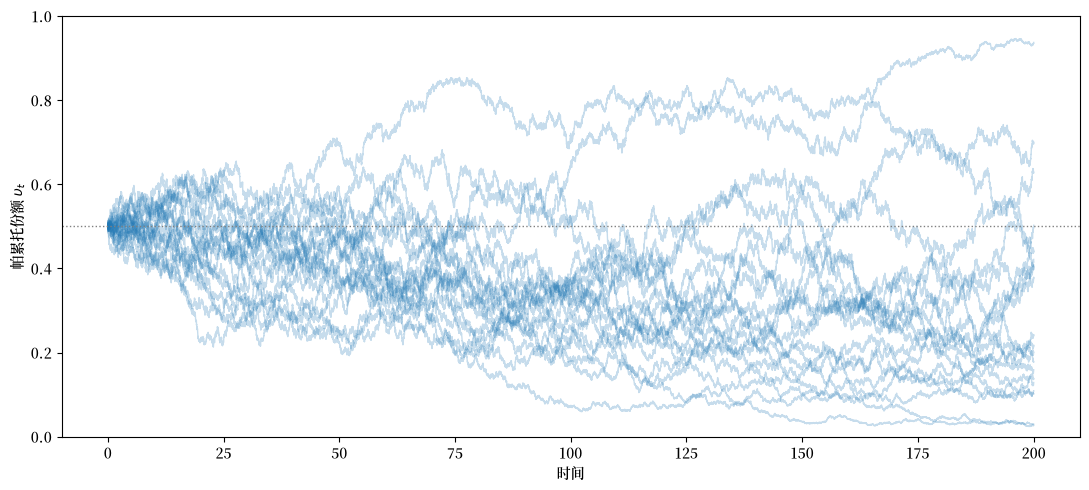

In [8]:
def simulate_crra_pareto(ω_1, ω_2, T, dt, n_paths, seed=42):
    """
    模拟可分基准中的帕累托份额动态。
    """
    rng = np.random.default_rng(seed)
    n_steps = int(T / dt)
    t_grid = np.linspace(0, T, n_steps + 1)

    drift = 0.5 * (ω_2**2 - ω_1**2)
    volatility = ω_1 - ω_2

    θ = np.zeros((n_paths, n_steps + 1))
    dW = rng.normal(0.0, np.sqrt(dt), size=(n_paths, n_steps))

    for t in range(n_steps):
        θ[:, t + 1] = θ[:, t] + drift * dt + volatility * dW[:, t]

    υ_paths = 1.0 / (1.0 + np.exp(-θ))
    return t_grid, υ_paths


ω_1 = 0.10
ω_2 = 0.0
t_grid, υ_paths = simulate_crra_pareto(ω_1, ω_2, T=200, dt=0.01, n_paths=50)

fig, ax = plt.subplots(figsize=(11, 5))

for i in range(20):
    ax.plot(t_grid, υ_paths[i], color="C0", alpha=0.25, lw=1)

ax.axhline(0.5, color="gray", linestyle=":", lw=1)
ax.set_xlabel("时间")
ax.set_ylabel(r"帕累托份额 $\upsilon_t$")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

此图模拟了在可分 CRRA 偏好($\gamma = \rho$)下帕累托份额 $\upsilon_t$ 的 20 条样本路径，其中 $\omega^1 = 0.10$ 且 $\omega^2 = 0$。

主体 2 具有正确信念，因此对数几率漂移为负，所有路径都趋向于 $\upsilon = 0$。

主体 1 被驱向消亡——这是 {cite:t}`Blume_Easley2006` 的经典市场选择结果。

## 资产定价含义

随着一个主体变得微不足道，当前价格收敛于由大主体构成的齐次经济体的价格。

当主体 2 是大主体时，{cite:t}`Borovicka2020` 中的命题 5.1 意味着

$$
\lim_{\upsilon \searrow 0} r(\upsilon)
= \beta + \rho \left(\mu_Y + \omega^2 \sigma_Y
+ \frac{1}{2} (1 - \gamma) \sigma_Y^2\right)
- \frac{1}{2} \gamma \sigma_Y^2
$$ (eq:riskfree)

以及

$$
\lim_{\upsilon \searrow 0} y(\upsilon)
= \left[
\beta - (1 - \rho)
\left(
\mu_Y + \omega^2 \sigma_Y + \frac{1}{2} (1 - \gamma) \sigma_Y^2
\right)
\right]^{-1} .
$$ (eq:wc_ratio)

总财富动态也收敛于齐次经济体的动态：

$$
\lim_{\upsilon \searrow 0} m_A(\upsilon) = \mu_Y,
\qquad
\lim_{\upsilon \searrow 0} \sigma_A(\upsilon) = \sigma_Y .
$$

命题 5.3 随后给出了微不足道主体自己的消费-储蓄和投资组合选择。

她的消费-财富比收敛于

$$
\lim_{\upsilon \searrow 0} (y^1(\upsilon))^{-1}
= (y(0))^{-1}
- \frac{1-\rho}{\rho}
\left[
(\omega^1 - \omega^2)\sigma_Y
+ \frac{(\omega^1 - \omega^2)^2}{2 \gamma}
\right] .
$$

小主体的风险资产份额收敛于

$$
\lim_{\upsilon \searrow 0} \pi^1(\upsilon)
= 1 + \frac{\omega^1 - \omega^2}{\gamma \sigma_Y} .
$$ (eq:portfolio)

因此乐观意味着杠杆，而足够强的悲观意味着做空。

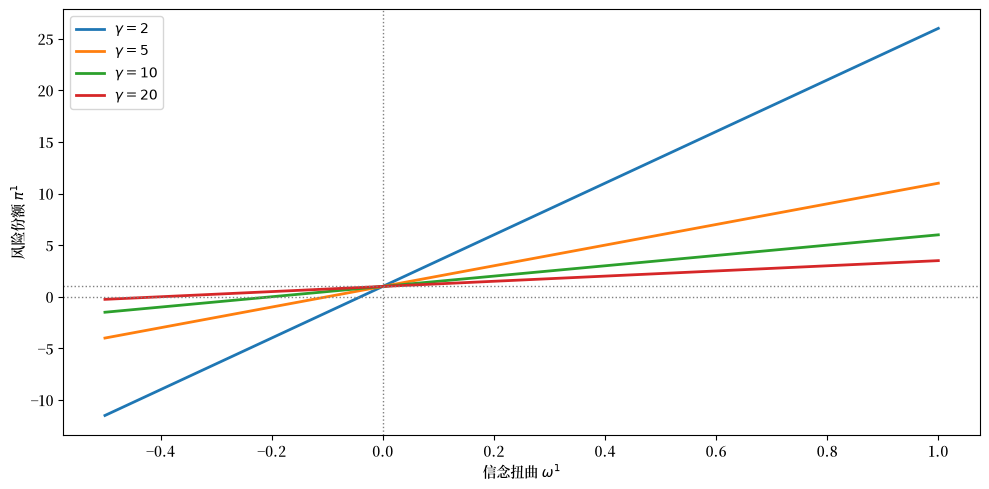

In [9]:
ω_2 = 0.0
σ_y = 0.02
ω_grid = np.linspace(-0.5, 1.0, 300)

fig, ax = plt.subplots(figsize=(10, 5))

for γ in [2, 5, 10, 20]:
    π_1 = 1 + (ω_grid - ω_2) / (γ * σ_y)
    ax.plot(ω_grid, π_1, lw=2, label=rf"$\gamma = {γ}$")

ax.axhline(1.0, color="gray", linestyle=":", lw=1)
ax.axhline(0.0, color="gray", linestyle=":", lw=1)
ax.axvline(0.0, color="gray", linestyle=":", lw=1)
ax.set_xlabel(r"信念扭曲 $\omega^1$")
ax.set_ylabel(r"风险份额 $\pi^1$")
ax.legend()
plt.tight_layout()
plt.show()

此图将微不足道主体的极限风险资产份额 $\pi^1$ 绘制为她的信念扭曲 $\omega^1$ 的函数($\omega^2 = 0$，$\sigma_Y = 0.02$)，针对四个风险厌恶水平。

在 $\omega^1 = 0$ 处，主体与主体 2 意见一致并持有市场投资组合($\pi^1 = 1$)。

乐观($\omega^1 > 0$)导致杠杆($\pi^1 > 1$)，而足够的悲观($\omega^1 < 0$)导致做空($\pi^1 < 0$)。

较高的风险厌恶将这些偏离压缩至接近 1。

## 乐观和悲观扭曲

乐观和悲观信念对生存的影响是不对称的。

乐观主体从风险溢价项中获益，并且当 IES $> 1$ 时，也从储蓄项中获益。

悲观主体放弃了风险溢价，只有当储蓄效应足够强以抵消该损失时才能生存。

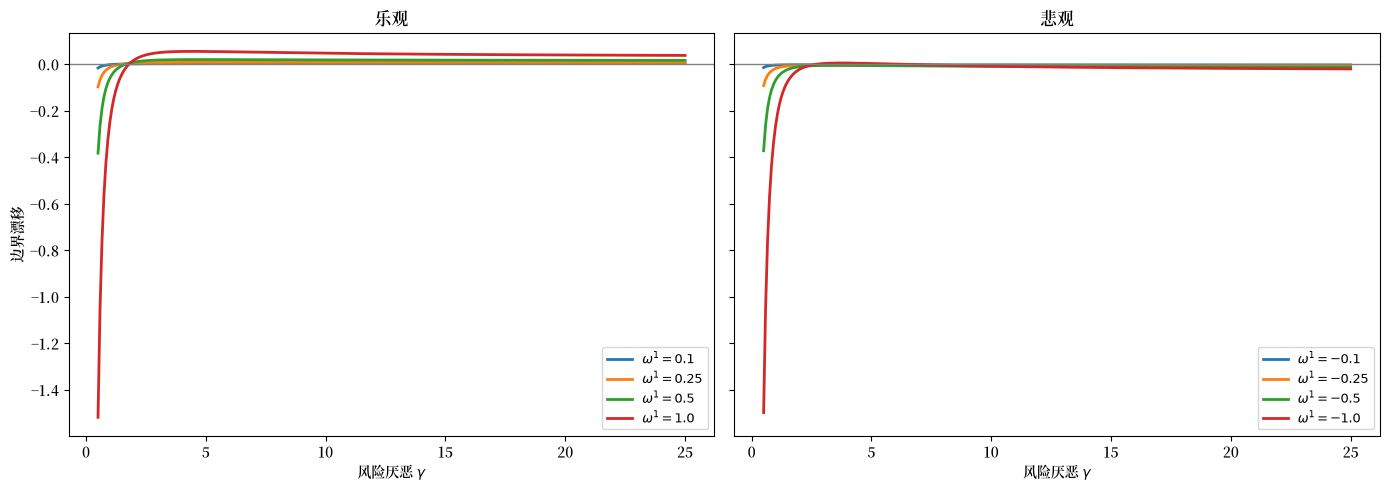

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

σ_y = 0.02
ω_2 = 0.0
ρ = 0.67
γ_grid = np.linspace(0.5, 25.0, 300)

ax = axes[0]
for ω_1 in [0.1, 0.25, 0.5, 1.0]:
    _, _, _, total = decompose_survival(ω_1, ω_2, γ_grid, ρ, σ_y)
    ax.plot(γ_grid, total, lw=2, label=rf"$\omega^1 = {ω_1}$")
ax.axhline(0, color="gray", lw=1)
ax.set_title("乐观", fontsize=12)
ax.set_xlabel(r"风险厌恶 $\gamma$")
ax.set_ylabel("边界漂移")
ax.legend(fontsize=9)

ax = axes[1]
for ω_1 in [-0.1, -0.25, -0.5, -1.0]:
    _, _, _, total = decompose_survival(ω_1, ω_2, γ_grid, ρ, σ_y)
    ax.plot(γ_grid, total, lw=2, label=rf"$\omega^1 = {ω_1}$")
ax.axhline(0, color="gray", lw=1)
ax.set_title("悲观", fontsize=12)
ax.set_xlabel(r"风险厌恶 $\gamma$")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

两个面板都将 $\upsilon = 0$ 处的总边界漂移绘制为 $\gamma$ 的函数(IES $\approx 1.49$，$\omega^2 = 0$)。

曲线为正的地方，主体 1 在接近消亡时生存。

- 左面板(乐观主体)：较大的 $\omega^1$ 意味着对风险资产更大的押注，因此波动率惩罚在低 $\gamma$ 时占主导，但一旦 $\gamma$ 足够大漂移转为正。
- 右面板(悲观主体)：悲观主体通过低配风险资产放弃了风险溢价，因此漂移在大部分参数空间内为负，生存需要足够强的储蓄动机以抵消投资组合损失。

## 长期消费分布

当两个主体都生存时，帕累托份额持续在整个区间 $(0, 1)$ 中移动。

下一个模拟只是一个玩具近似。

它在两个边界值之间插值漂移，因此在不求解完整均衡 ODE 的情况下说明了常返逻辑。

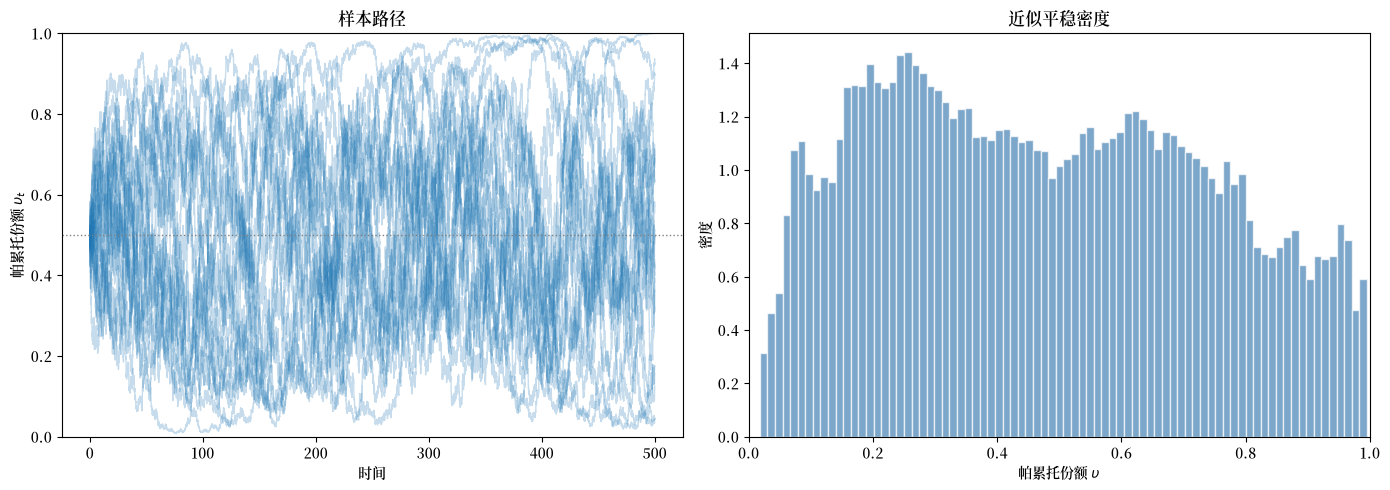

In [11]:
def simulate_pareto_share_toy(ω_1, ω_2, γ, ρ, σ_y, T, dt, n_paths=20, seed=42):
    """
    通过插值边界漂移模拟玩具帕累托份额过程。
    """
    rng = np.random.default_rng(seed)
    n_steps = int(T / dt)
    t_grid = np.linspace(0, T, n_steps + 1)

    volatility = ω_1 - ω_2
    m_0 = boundary_drift(ω_1, ω_2, γ, ρ, σ_y)
    m_1 = -boundary_drift(ω_2, ω_1, γ, ρ, σ_y)

    θ = np.zeros((n_paths, n_steps + 1))
    dW = rng.normal(0.0, np.sqrt(dt), size=(n_paths, n_steps))

    for t in range(n_steps):
        υ = 1.0 / (1.0 + np.exp(-θ[:, t]))
        drift = m_0 * (1 - υ) + m_1 * υ
        θ[:, t + 1] = θ[:, t] + drift * dt + volatility * dW[:, t]

    υ_paths = 1.0 / (1.0 + np.exp(-θ))
    return t_grid, υ_paths


ω_1 = 0.25
ω_2 = 0.0
γ = 5.0
ρ = 0.67
σ_y = 0.02

t_grid, υ_paths = simulate_pareto_share_toy(
    ω_1, ω_2, γ, ρ, σ_y, T=500, dt=0.05, n_paths=50, seed=42
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for i in range(20):
    ax.plot(t_grid, υ_paths[i], color="C0", alpha=0.25, lw=1)
ax.axhline(0.5, color="gray", linestyle=":", lw=1)
ax.set_title("样本路径", fontsize=12)
ax.set_xlabel("时间")
ax.set_ylabel(r"帕累托份额 $\upsilon_t$")
ax.set_ylim(0, 1)

ax = axes[1]
_, υ_long = simulate_pareto_share_toy(
    ω_1, ω_2, γ, ρ, σ_y, T=2000, dt=0.05, n_paths=5, seed=123
)
υ_stationary = υ_long[:, υ_long.shape[1] // 2:].ravel()
ax.hist(υ_stationary, bins=80, density=True, color="steelblue",
        edgecolor="white", alpha=0.7)
ax.set_title("近似平稳密度", fontsize=12)
ax.set_xlabel(r"帕累托份额 $\upsilon$")
ax.set_ylabel("密度")
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

左面板显示了在共存区域内的参数下帕累托份额 $\upsilon_t$ 的 20 条样本路径($\omega^1 = 0.25$，$\omega^2 = 0$，$\gamma = 5$，IES $\approx 1.49$)。

与 {numref}`fig-crra-pareto-paths` 中的可分情形不同，这些路径不会漂向零——它们反复访问广泛的取值范围，在两个排斥边界之间来回弹跳。

右面板通过汇集较长模拟的后半部分来近似平稳密度。

内部模态与两个主体都不被驱向消亡相一致。

然而，这个玩具插值仅仅说明了常返逻辑；它并不重现 {cite:t}`Borovicka2020` 图 4 中定量的平稳消费份额密度，后者需要求解完整的内部均衡 ODE。

## 总结

递归偏好削弱了经典的市场选择结果。

投资组合收益渠道仍然奖励更乐观的信念。

波动率渠道仍然惩罚激进的头寸。

但当 IES $> 1$ 时，储蓄渠道可以足够强以使具有扭曲信念的主体存活。

这就是为什么递归偏好经济体可以支持在信念和投资组合头寸方面具有持续异质性的平稳长期财富分布。